# 05 — Interpretation of Mutation Effects

In this step, I interpret the predicted stability effects of mutations based on structural context and amino acid chemistry.

The goal is to connect the scoring results to known principles of protein stability, including:
- hydrophobic core packing
- electrostatics
- solvent exposure

***Load results***

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/mutation_scores.csv")
df

,mutation_id,position,resname_3,resname_1,wt,mut,environment_group,environment,ss_simple,rsa,mutation_class,rationale,stability_score,predicted_effect
0,L8I,8,LEU,L,L,I,core,core,helix,0.000000,conservative,Maintains hydrophobic character with similar s...,2,stabilizing
1,L8A,8,LEU,L,L,A,core,core,helix,0.000000,moderate,Reduces side-chain volume and may create a cav...,-2,destabilizing
2,L8D,8,LEU,L,L,D,core,core,helix,0.000000,disruptive,Introduces a charged residue into the buried c...,-6,destabilizing
3,V29I,29,VAL,V,V,I,core,core,helix,0.000000,conservative,Retains hydrophobic chemistry with a similar b...,2,stabilizing
4,V29A,29,VAL,V,V,A,core,core,helix,0.000000,moderate,Shrinks side-chain volume and may weaken tight...,-2,destabilizing
5,V29D,29,VAL,V,V,D,core,core,helix,0.000000,disruptive,Introduces a charged residue into a buried hyd...,-6,destabilizing
6,L56I,56,LEU,L,L,I,core,core,loop,0.000000,conservative,Maintains hydrophobic character with similar s...,2,stabilizing
7,L56A,56,LEU,L,L,A,core,core,loop,0.000000,moderate,Reduces side-chain volume and may create a cav...,-2,destabilizing
8,L56D,56,LEU,L,L,D,core,core,loop,0.000000,disruptive,Introduces a charged residue into the buried c...,-6,destabilizing
9,D18E,18,ASP,D,D,E,surface,surface,loop,0.343558,conservative,Retains negative charge while slightly extendi...,1,stabilizing


***Group by environment***

In [3]:
print("Core mutations:")
display(df[df["environment_group"] == "core"])

print("\nSurface mutations:")
display(df[df["environment_group"] == "surface"])

Core mutations:


,mutation_id,position,resname_3,resname_1,wt,mut,environment_group,environment,ss_simple,rsa,mutation_class,rationale,stability_score,predicted_effect
0,L8I,8,LEU,L,L,I,core,core,helix,0.0,conservative,Maintains hydrophobic character with similar s...,2,stabilizing
1,L8A,8,LEU,L,L,A,core,core,helix,0.0,moderate,Reduces side-chain volume and may create a cav...,-2,destabilizing
2,L8D,8,LEU,L,L,D,core,core,helix,0.0,disruptive,Introduces a charged residue into the buried c...,-6,destabilizing
3,V29I,29,VAL,V,V,I,core,core,helix,0.0,conservative,Retains hydrophobic chemistry with a similar b...,2,stabilizing
4,V29A,29,VAL,V,V,A,core,core,helix,0.0,moderate,Shrinks side-chain volume and may weaken tight...,-2,destabilizing
5,V29D,29,VAL,V,V,D,core,core,helix,0.0,disruptive,Introduces a charged residue into a buried hyd...,-6,destabilizing
6,L56I,56,LEU,L,L,I,core,core,loop,0.0,conservative,Maintains hydrophobic character with similar s...,2,stabilizing
7,L56A,56,LEU,L,L,A,core,core,loop,0.0,moderate,Reduces side-chain volume and may create a cav...,-2,destabilizing
8,L56D,56,LEU,L,L,D,core,core,loop,0.0,disruptive,Introduces a charged residue into the buried c...,-6,destabilizing



Surface mutations:


,mutation_id,position,resname_3,resname_1,wt,mut,environment_group,environment,ss_simple,rsa,mutation_class,rationale,stability_score,predicted_effect
9,D18E,18,ASP,D,D,E,surface,surface,loop,0.343558,conservative,Retains negative charge while slightly extendi...,1,stabilizing
10,D18N,18,ASP,D,D,N,surface,surface,loop,0.343558,moderate,Removes formal charge but preserves polar hydr...,-1,destabilizing
11,D18F,18,ASP,D,D,F,surface,surface,loop,0.343558,disruptive,Introduces a hydrophobic aromatic residue at a...,-3,destabilizing
12,R73K,73,ARG,R,R,K,surface,surface,loop,0.625000,conservative,Retains positive charge with similar surface e...,1,stabilizing
13,R73Q,73,ARG,R,R,Q,surface,surface,loop,0.625000,moderate,Removes positive charge while keeping a polar ...,-1,destabilizing
14,R73F,73,ARG,R,R,F,surface,surface,loop,0.625000,disruptive,Introduces a bulky hydrophobic aromatic residu...,-3,destabilizing
15,Q41N,41,GLN,Q,Q,N,surface,surface,loop,0.606061,conservative,Retains polar amide chemistry with a slightly ...,1,stabilizing
16,Q41E,41,GLN,Q,Q,E,surface,surface,loop,0.606061,moderate,Introduces a negative charge at a previously n...,-1,destabilizing
17,Q41F,41,GLN,Q,Q,F,surface,surface,loop,0.606061,disruptive,Replaces a polar surface residue with a hydrop...,-3,destabilizing


***Summarize patterns***

In [4]:
print("Effect by environment:")
print(df.groupby("environment_group")["predicted_effect"].value_counts())

Effect by environment:
environment_group  predicted_effect
core               destabilizing       6
                   stabilizing         3
surface            destabilizing       6
                   stabilizing         3
Name: count, dtype: int64


## Key Observations

### 1. Core mutations are highly sensitive

All disruptive mutations in the core (e.g., L→D, V→D) show strong destabilization.

This is consistent with protein folding principles:
- the hydrophobic core is tightly packed
- introducing charged residues is energetically unfavorable
- this can disrupt folding and stability

### 2. Conservative mutations are tolerated

Conservative substitutions (e.g., L→I, V→I) maintain hydrophobic interactions and are predicted to be stabilizing or neutral.

### 3. Surface mutations are more tolerant

Surface residues show milder effects:
- conservative mutations are stabilizing
- disruptive mutations are less severe than in the core

This reflects solvent exposure, where:
- residues are not tightly packed
- changes are less structurally disruptive

### 4. Chemical nature of mutation matters

The most destabilizing mutations introduce:
- charge into the hydrophobic core
- hydrophobic residues into polar surface environments

These results align with known protein engineering principles.

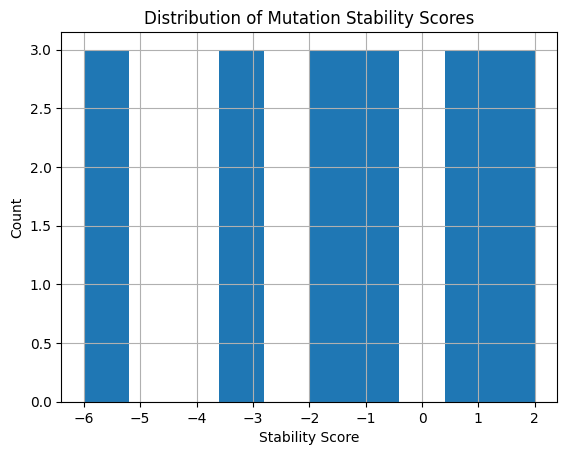

In [5]:
import matplotlib.pyplot as plt

df["stability_score"].hist()
plt.title("Distribution of Mutation Stability Scores")
plt.xlabel("Stability Score")
plt.ylabel("Count")
plt.show()